<table>
<tr><td><img style="height: 150px;" src="images/geo_hydro1.jpg"></td>
<td bgcolor="#FFFFFF">
    <p style="font-size: xx-large; font-weight: 900; line-height: 100%">AG Dynamics of the Earth</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Juypter notebooks</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Georg Kaufmann</p>
    </td>
</tr>
</table>

# Machine learning: Classification task applied to iris data set

## Natural neighbors
----
*Georg Kaufmann,
Geophysics Section,
Institute of Geological Sciences,
Freie Universität Berlin,
Germany*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap 
import csv

### Load data set

First, we load the cleaned iris data set. Instead of the pandas library, this time we load the csv file 
with the `csv` library.

As first step, we define a matrix $X_{ij}$,holding the $j=1,m$ **parameter values** for each
observation $i=1,n$, and a vector $y_i$ holding the flower names as **observation** for each $i=1,n$.

With the capital $X$ and the small $y$, we follow the machine-learning nomenclature ...

We then read the csv file, first as signle line the header (we do not need it), then
as for loop the remaining 150 lines.

Note: we need to change the flower names to numbers ...

In [2]:
n=150
m=4
X = np.zeros([n*m]).reshape(n,m)
y = np.zeros([n])

csvfile = open('data/iris.csv', newline='')
iris = csv.reader(csvfile, delimiter=',')
next(iris)
i=0
for row in iris:
    X[i,0] = row[0]
    X[i,1] = row[1]
    X[i,2] = row[2]
    X[i,3] = row[3]
    if (row[4]=='Iris-setosa'):
        y[i] = 0
    elif (row[4]=='Iris-versicolor'):
        y[i] = 1
    elif (row[4]=='Iris-virginica'):
        y[i] = 2
    i=i+1
print(X.ndim,X.shape,X[0])
print(y.ndim,y.shape,y[0])

2 (150, 4) [5.1 3.5 1.4 0.2]
1 (150,) 0.0


----
### Fit with natural neighbors


In [3]:
from sklearn import neighbors
clf = neighbors.KNeighborsClassifier(n_neighbors=1)

[[<matplotlib.axes._subplots.AxesSubplot object at 0x11318a748>


AttributeError: 'numpy.ndarray' object has no attribute 'set_xlim'

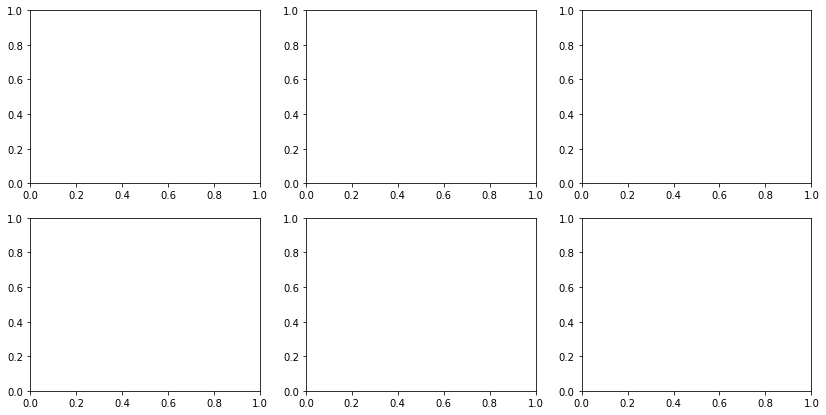

In [10]:
fig, gerd = plt.subplots(2, 3, figsize=(14,7), sharey=False)
print(gerd)
#colors = 'bwr'#['b','y','r']
#CMAP = colors#plt.cm.rainbow
#h=0.02
#--------0,1------------
#pair=[0,1]
#X = X[:, pair]
#clf.fit(X, y)
#x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
#y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
#xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
#                    np.arange(y_min, y_max, h))
#Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
#Z = Z.reshape(xx.shape)

gerd[0].set_xlim([11,12])
#axs[0].pcolormesh(xx, yy, Z, cmap=CMAP, alpha=0.5)
#axs[0].set_xlim(xx.min(), xx.max())
#axs[0].set_ylim(yy.min(), yy.max())

In [ ]:
clf = neighbors.KNeighborsClassifier(n_neighbors=1)

In [ ]:
clf.fit(X_train, y_train)

In [ ]:
clf.predict([[5.1,3.5,1.4,0.2]])

In [ ]:
clf.score(X_train,y_train)

In [ ]:
clf.score(X_test,y_test)

As this check is a bit dry, we create plots of the fit. We have four variables
(sepal length and width, petal length and width), therefore plotting all dependencies is
impossible.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
font_size=20

def meshGrid(x_data, y_data):
    h = .02  # step size in the mesh
    x_min, x_max = x_data.min() - 1, x_data.max() + 1
    y_min, y_max = y_data.min() - 1, y_data.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return (xx,yy)
    
def plotPrediction(clf,x_train,y_train,x_test,y_test,x_label,y_label,col_train,col_test, title="", mesh=True):
    xx_train,yy_train = meshGrid(x_train, y_train)
    Z_train = clf.predict(np.c_[xx_train.ravel(), yy_train.ravel()])
    xx_test,yy_test = meshGrid(x_test, y_test)
    Z_test = clf.predict(np.c_[xx_test.ravel(), yy_test.ravel()])

    # Put the result into a color plot
    Z_train = Z_train.reshape(xx_train.shape)
    Z_test  = Z_test.reshape(xx_test.shape)
    
    fig, axs = plt.subplots(1, 2, figsize=(14,7), sharey=False)
    if mesh:
        axs[0].pcolormesh(xx_train, yy_train, Z_train, cmap=cmap_light)
    axs[0].set_xlim(xx_train.min(), xx_train.max())
    axs[0].set_ylim(yy_train.min(), yy_train.max())
    axs[0].set_xlabel(x_label, fontsize=font_size)
    axs[0].set_ylabel(y_label, fontsize=font_size)
    axs[0].set_title('train data', fontsize=font_size)
    axs[0].scatter(x_train, y_train, c=col_train, cmap=cmap_bold, s=80, marker='o')

    if mesh:
        axs[1].pcolormesh(xx_test, yy_test, Z_test, cmap=cmap_light)
    axs[1].set_xlim(xx_test.min(), xx_test.max())
    axs[1].set_ylim(yy_test.min(), yy_test.max())
    axs[1].set_xlabel(x_label, fontsize=font_size)
    axs[1].set_ylabel(y_label, fontsize=font_size)
    axs[1].set_title('test data', fontsize=font_size)
    axs[1].scatter(x_test, y_test, c=col_test, cmap=cmap_bold, s=80, marker='o')

    fig.suptitle(title, fontsize=font_size)

Test for sepal features only with **one** natural neighbor:

In [ ]:
nn=1
X_train_sepal_only = X_train[:, :2]
X_test_sepal_only = X_test[:, :2]
clf_sepal = neighbors.KNeighborsClassifier(n_neighbors=nn)
clf_sepal.fit(X_train_sepal_only, y_train)

print('Score fit train data: ',clf_sepal.score(X_train_sepal_only, y_train))
print('Score fit test data:  ',clf_sepal.score(X_test_sepal_only, y_test))
plotPrediction(clf_sepal, 
               X_train_sepal_only[:, 0], X_train_sepal_only[:, 1],
               X_test_sepal_only[:, 0], X_test_sepal_only[:, 1],
               'Sepal length', 'Sepal width', y_train,y_test, mesh=True,
                title="Data for Sepal Features (n="+str(nn)+")")

In [ ]:
nn=10
X_train_sepal_only = X_train[:, :2]
X_test_sepal_only = X_test[:, :2]
clf_sepal = neighbors.KNeighborsClassifier(n_neighbors=nn)
clf_sepal.fit(X_train_sepal_only, y_train)

print('Score fit train data: ',clf_sepal.score(X_train_sepal_only, y_train))
print('Score fit test data:  ',clf_sepal.score(X_test_sepal_only, y_test))
plotPrediction(clf_sepal, 
               X_train_sepal_only[:, 0], X_train_sepal_only[:, 1],
               X_test_sepal_only[:, 0], X_test_sepal_only[:, 1],
               'Sepal length', 'Sepal width', y_train,y_test, mesh=True,
                title="Data for Sepal Features (n="+str(nn)+")")

In [ ]:
nn=10
X_train_petal_only = X_train[:, 2:]
X_test_petal_only = X_test[:, 2:]

clf_petal = neighbors.KNeighborsClassifier(n_neighbors=nn)
clf_petal.fit(X_train_petal_only, y_train)

print('Score fit train data: ',clf_petal.score(X_train_petal_only, y_train))
print('Score fit test data:  ',clf_petal.score(X_test_petal_only, y_test))
plotPrediction(clf_petal, 
               X_train_petal_only[:, 0], X_train_petal_only[:, 1],
               X_test_petal_only[:, 0], X_test_petal_only[:, 1],
               'Petal length', 'Petal width', y_train,y_test, mesh=True,
                title="Data for Petal Features (n="+str(nn)+")")

## Pairing the features

[next>](03_iris2.ipynb)